# Paper [IDETC]: Human Failure Representation

This paper covers the exploration and analysis of error producing conditions by a human operator in the rover model.

For the paper `Irshad, L., & Hulse, D. (2022, August). Resilience modeling in complex engineered systems with human-machine interactions. In International Design Engineering Technical Conferences and Computers and Information in Engineering Conference (Vol. 86212, p. V002T02A024). American Society of Mechanical Engineers.`

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```


In [1]:
from fmdtools_examples.navigating_rover.model_human import RoverHuman
from fmdtools_examples.navigating_rover.model_main import plot_map

import fmdtools.sim.propagate as prop
import fmdtools.analyze as an
from fmdtools.sim.sample import ParameterSample, ParameterDomain, FaultSample, FaultDomain

import numpy as np
import matplotlib.pyplot as plt

Visualizing Rover Structure

In [2]:
mdl = RoverHuman()
mdl.fxns

{'power': power Power
 - t=Time(time=-0.1, timers={})
 - s=PowerState(charge=100.0, power=0.0)
 - m=PowerMode(mode='off', faults=set(), sub_faults=False)
 - ee_15=EE(s=(v=0.0, a=0.0))
 - ee_5=EE(s=(v=0.0, a=0.0))
 - ee_12=EE(s=(v=0.0, a=0.0))
 - switch=Switch(s=(power=False)),
 'perception': perception Perception
 - t=Time(time=-0.1, timers={})
 - m=PerceptionMode(mode='off', faults=set(), sub_faults=False)
 - pos=Pos(s=(x=0.0, y=0.0, vel=0.0, ux=1.0, uy=0.0))
 - pos_signal=Pos(s=(x=0.0, y=0.0, vel=0.0, ux=1.0, uy=0.0))
 - ground=Ground(s=(in_bound=True), c=(), ga=())
 - ee=EE(s=(v=0.0, a=0.0))
 - video=Video(s=(lin_ux=1.0, lin_uy=0.0, lin_dx=0.0, lin_dy=0.0, quality=1.0)),
 'communications': communications Communications
 - t=Time(time=-0.1, timers={})
 - ee_12=EE(s=(v=0.0, a=0.0))
 - comms=Comms(s=(pos=PosState(x=0.0, y=0.0, vel=0.0, ux=1.0, uy=0.0), ctl=ControlState(rpower=0.0, lpower=0.0), video...
 - pos_signal=Pos(s=(x=0.0, y=0.0, vel=0.0, ux=1.0, uy=0.0))
 - video=Video(s=(lin_u

In [3]:
#%matplotlib qt
#an.graph.set_pos(mdl, gtype='fxnflowgraph')

In [4]:
#%matplotlib inline

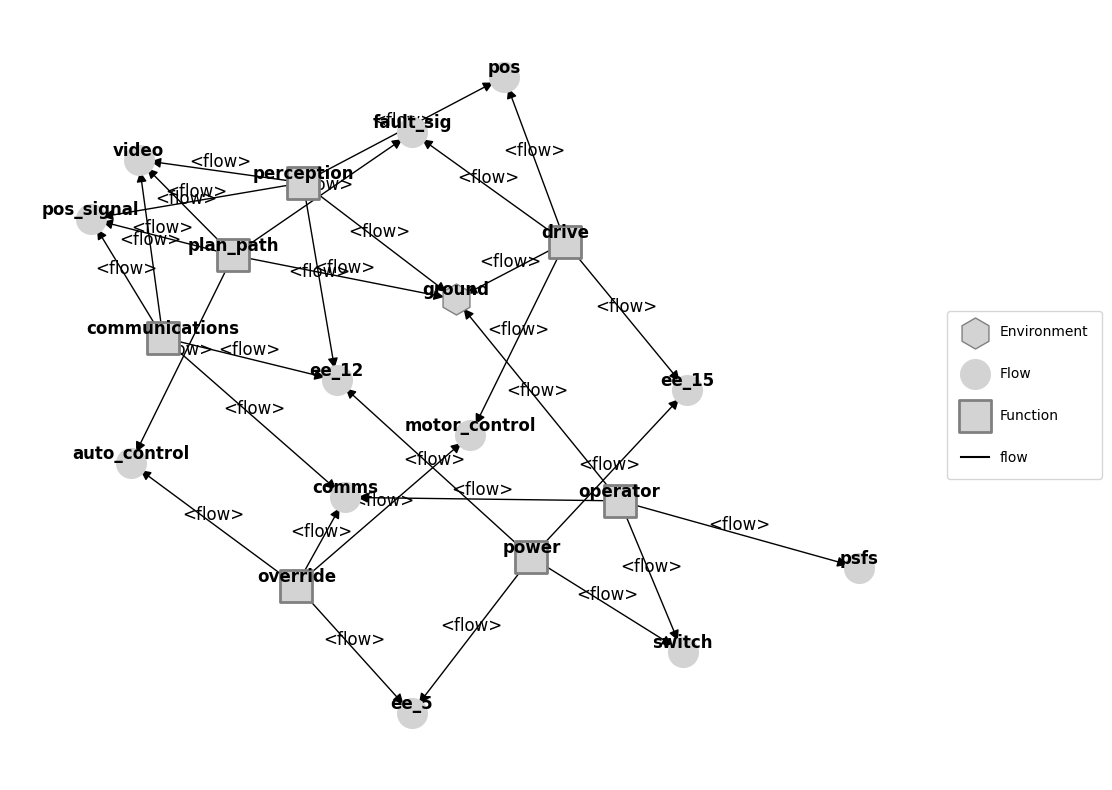

In [5]:
g = mdl.as_modelgraph()
fig, ax = g.draw()

In [6]:
fig.savefig("outputs_paper_idetc_human/rover_structure.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

Visualizing Action Sequence Graph for the Controller

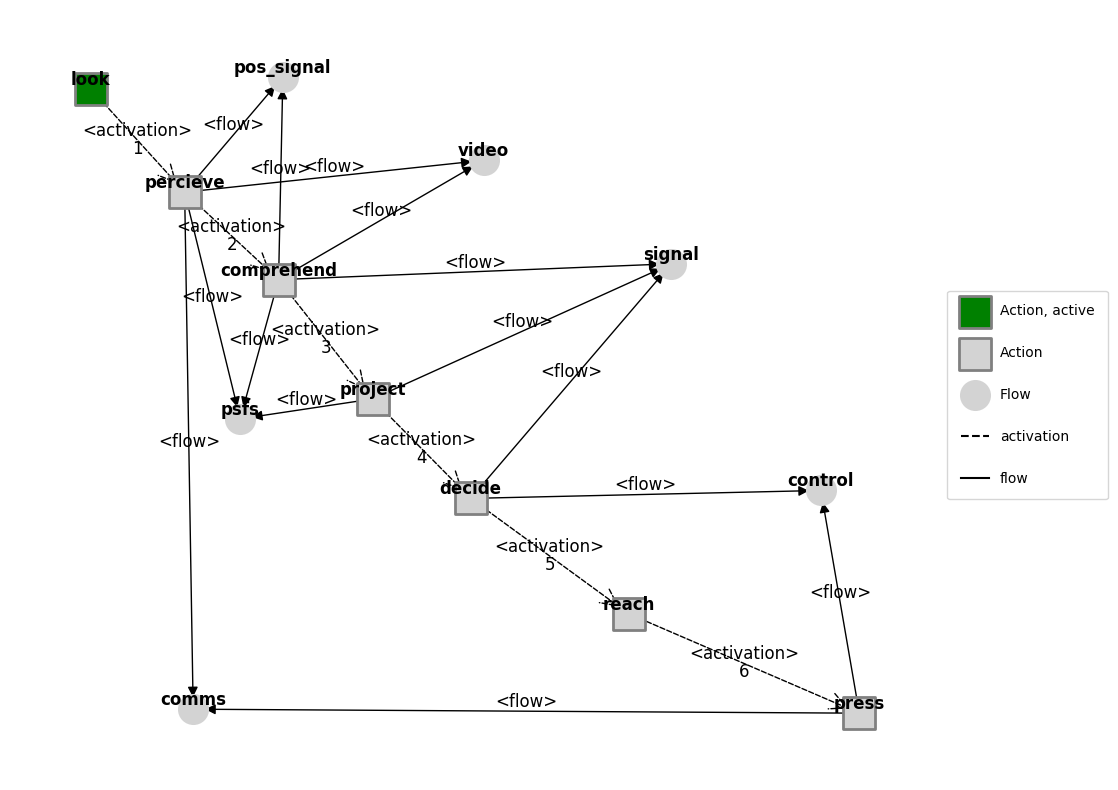

In [7]:
from fmdtools_examples.navigating_rover.model_human import asg_pos
ag = mdl.fxns['operator'].aa.as_modelgraph()
ag.set_pos(**asg_pos)
fig, ax = ag.draw()

In [8]:
fig.savefig("outputs_paper_idetc_human/action_graph.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

## Testing behavioral simulation

Execution order

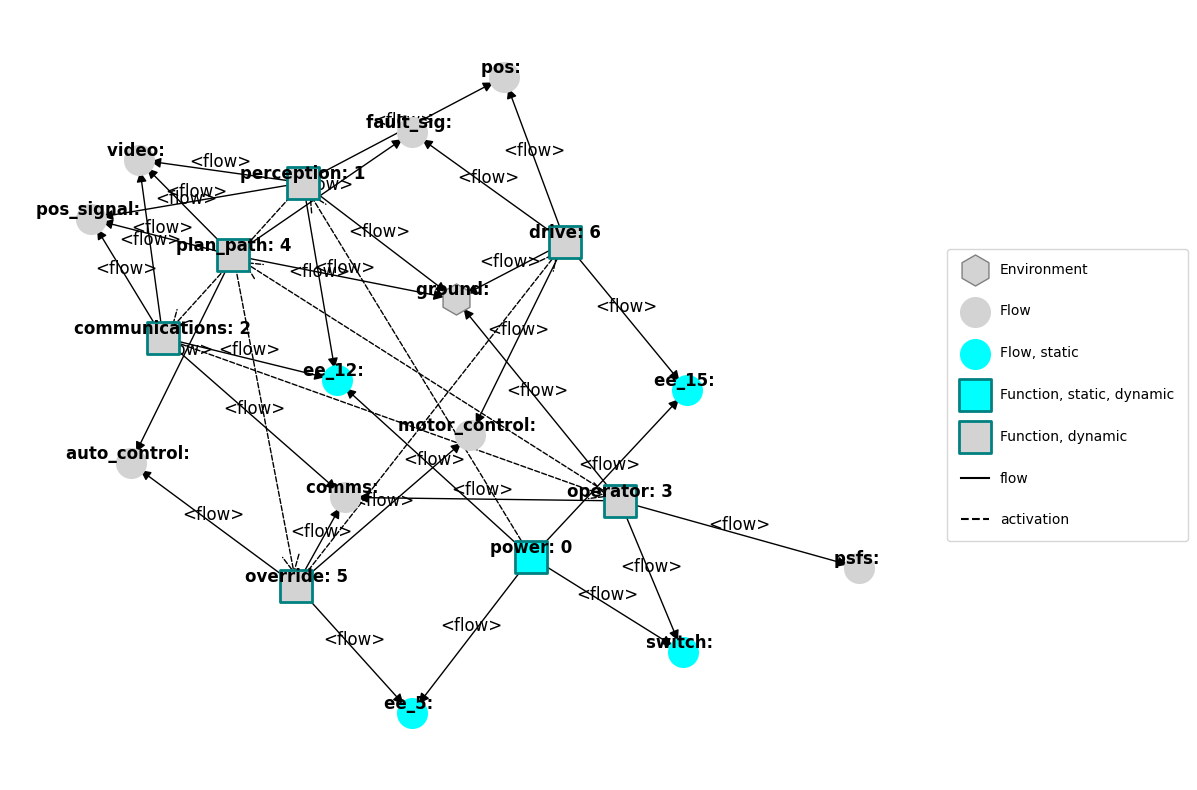

In [9]:
g.set_exec_order(mdl)
fig, ax = g.draw()

Performance on turn

(<Figure size 400x400 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

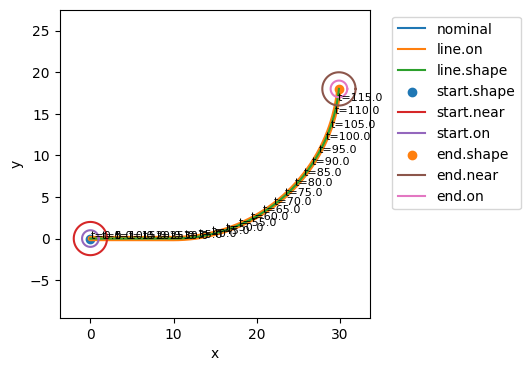

In [10]:
mdl = RoverHuman(p={'ground': 'turn'})
endresults, mdlhist = prop.nominal(mdl)
plot_map(mdl, mdlhist)

Performance on sine map

(<Figure size 400x400 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

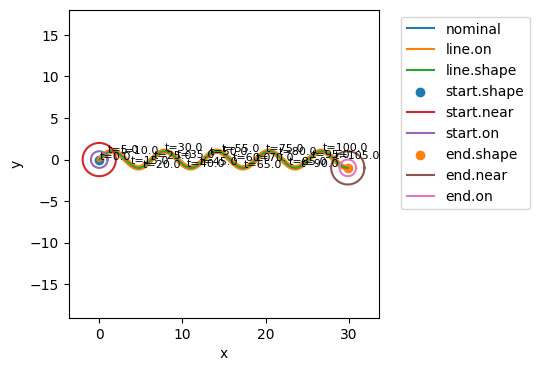

In [11]:
mdl = RoverHuman()
endresults, mdlhist = prop.nominal(mdl)
plot_map(mdl, mdlhist)

In [12]:
from fmdtools.analyze.phases import from_hist
pm = from_hist(mdlhist)

In [13]:
pm

{'power': PhaseMap({np.str_('off'): [np.float64(0.0), np.float64(0.0)], np.str_('supply'): [np.float64(1.0), np.float64(109.0)]}, {np.str_('off'): {np.str_('off')}, np.str_('supply'): {np.str_('supply')}}),
 'perception': PhaseMap({np.str_('off'): [np.float64(0.0), np.float64(1.0)], np.str_('feed'): [np.float64(2.0), np.float64(109.0)]}, {np.str_('off'): {np.str_('off')}, np.str_('feed'): {np.str_('feed')}}),
 'look': PhaseMap({np.str_('nominal'): [np.float64(0.0), np.float64(109.0)]}, {np.str_('nominal'): {np.str_('nominal')}}),
 'percieve': PhaseMap({np.str_('nominal'): [np.float64(0.0), np.float64(0.0)], np.str_('no_action'): [np.float64(1.0), np.float64(1.0)], 'nominal1': [np.float64(2.0), np.float64(109.0)]}, {np.str_('nominal'): {np.str_('nominal'), 'nominal1'}, np.str_('no_action'): {np.str_('no_action')}}),
 'comprehend': PhaseMap({np.str_('nominal'): [np.float64(0.0), np.float64(109.0)]}, {np.str_('nominal'): {np.str_('nominal')}}),
 'project': PhaseMap({np.str_('nominal'): [n

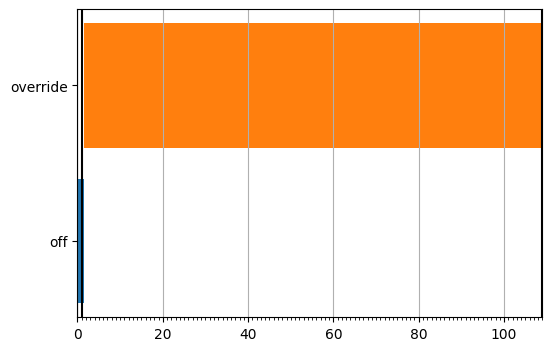

In [14]:
phase_fig = pm['override'].plot()

## Testing Faults

In [15]:
#app=SampleApproach(mdl, faults='Controller', phases={'drive':phases['Operations']['drive']})

fd = FaultDomain(mdl)
fd.add_all_fxn_modes('operator')
fd

FaultDomain with faults:
 -('roverhuman.fxns.operator.aa.acts.look', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'not_visible')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'wrong_position')
 -('roverhuman.fxns.operator.aa.acts.comprehend', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_fast')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_slow')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_turn_left')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_turn_right')
 -...more

In [16]:
fs = FaultSample(fd, phasemap = pm['override'])
fs.add_fault_phases('override')
fs

FaultSample of scenarios: 
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t56p0
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t56p0
 - roverhuman_fxns_operator_aa_acts_percieve_not_visible_t56p0
 - roverhuman_fxns_operator_aa_acts_percieve_wrong_position_t56p0
 - roverhuman_fxns_operator_aa_acts_comprehend_failed_no_action_t56p0
 - roverhuman_fxns_operator_aa_acts_project_failed_fast_t56p0
 - roverhuman_fxns_operator_aa_acts_project_failed_no_action_t56p0
 - roverhuman_fxns_operator_aa_acts_project_failed_slow_t56p0
 - roverhuman_fxns_operator_aa_acts_project_failed_turn_left_t56p0
 - roverhuman_fxns_operator_aa_acts_project_failed_turn_right_t56p0
 - ... (19 total)

In [17]:
fs.scenarios()

[SingleFaultScenario(sequence={56.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.look': ['failed_no_action']}, disturbances={})}, times=(np.float64(56.0),), function='roverhuman.fxns.operator.aa.acts.look', fault='failed_no_action', rate=np.float64(1.0), name='roverhuman_fxns_operator_aa_acts_look_failed_no_action_t56p0', time=np.float64(56.0), phase=np.str_('override')),
 SingleFaultScenario(sequence={56.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.percieve': ['failed_no_action']}, disturbances={})}, times=(np.float64(56.0),), function='roverhuman.fxns.operator.aa.acts.percieve', fault='failed_no_action', rate=np.float64(1.0), name='roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t56p0', time=np.float64(56.0), phase=np.str_('override')),
 SingleFaultScenario(sequence={56.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.percieve': ['not_visible']}, disturbances={})}, times=(np.float64(56.0),), function='roverhuman.fxns.operator.aa.acts.percieve', faul

In [18]:
ecs, hists = prop.fault_sample(mdl, fs)

SCENARIOS COMPLETE: 100%|██████████| 19/19 [00:04<00:00,  4.10it/s]


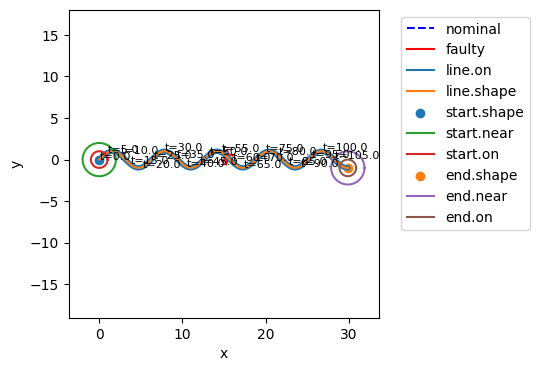

In [19]:
fig, ax = plot_map(mdl, hists)

(-5.0, 5.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


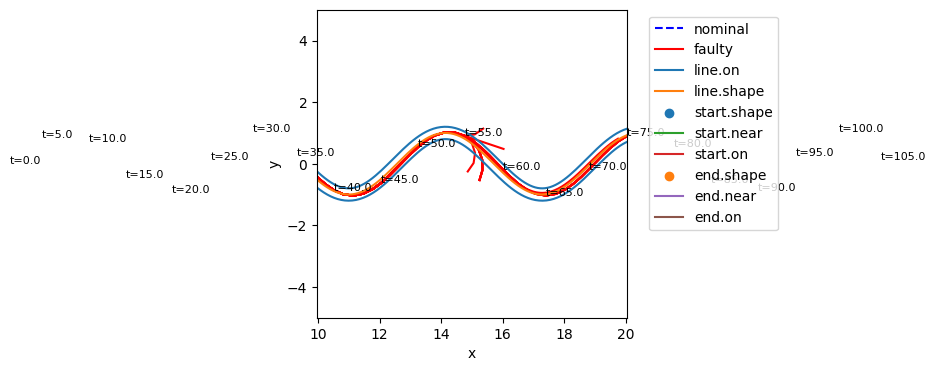

In [20]:
fig, ax = plot_map(mdl, hists)
ax.set_xlim(10, 20)
ax.set_ylim(-5, 5)

In [21]:
fig.savefig("outputs_paper_idetc_human/rover_map.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

Below shows the impact of each fault:

In [22]:
tab = an.tabulate.result_summary_fmea(ecs, hists,
                                      *mdl.flows, *mdl.fxns,
                                      metrics = ["in_bound", "at_finish", "end_dist", "faults", "classification", "end_x", "end_y"])
tab

,degraded,faulty,in_bound,at_finish,end_dist,faults,classification,end_x,end_y
nominal,[],[],True,True,0.0,[],nominal mission,29.254775,-0.782764
roverhuman_fxns_operator_aa_acts_look_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,[look.failed_no_action],incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t56p0,[],[],True,True,0.0,[],nominal mission,29.254775,-0.782764
roverhuman_fxns_operator_aa_acts_percieve_not_visible_t56p0,[],[],True,True,0.0,[],nominal mission,29.254775,-0.782764
roverhuman_fxns_operator_aa_acts_percieve_wrong_position_t56p0,[],[],True,True,0.0,[],nominal mission,29.254775,-0.782764
roverhuman_fxns_operator_aa_acts_comprehend_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,"[percieve.not_visible, comprehend.failed_no_ac...",incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_project_failed_fast_t56p0,"['ground', 'pos_signal', 'pos', 'ee_15', 'vide...",['operator'],False,False,12.955107,"[percieve.not_visible, project.failed_fast]",incomplete mission faulty,16.023518,0.480458
roverhuman_fxns_operator_aa_acts_project_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,"[percieve.not_visible, project.failed_no_action]",incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_project_failed_slow_t56p0,"['psfs', 'pos_signal', 'pos', 'ee_15', 'video'...",['operator'],True,False,9.31949,[project.failed_slow],incomplete mission faulty,19.740872,0.81243
roverhuman_fxns_operator_aa_acts_project_failed_turn_left_t56p0,"['ground', 'pos_signal', 'pos', 'video', 'auto...",['operator'],False,False,14.057688,"[percieve.not_visible, project.failed_turn_left]",incomplete mission faulty,14.862043,-0.251773


In [23]:
tab.sort_values('end_dist', ascending=False)

,degraded,faulty,in_bound,at_finish,end_dist,faults,classification,end_x,end_y
roverhuman_fxns_operator_aa_acts_decide_failed_turn_right_t56p0,"['psfs', 'pos_signal', 'pos', 'ee_15', 'video'...",['operator'],True,False,14.2601,[decide.failed_turn_right],incomplete mission faulty,14.759409,0.904491
roverhuman_fxns_operator_aa_acts_decide_failed_fast_t56p0,"['psfs', 'pos_signal', 'pos', 'ee_15', 'video'...",['operator'],True,False,14.2601,[decide.failed_fast],incomplete mission faulty,14.759409,0.904491
roverhuman_fxns_operator_aa_acts_decide_failed_slow_t56p0,"['psfs', 'pos_signal', 'pos', 'ee_15', 'video'...",['operator'],True,False,14.2601,[decide.failed_slow],incomplete mission faulty,14.759409,0.904491
roverhuman_fxns_operator_aa_acts_decide_failed_turn_left_t56p0,"['psfs', 'pos_signal', 'pos', 'ee_15', 'video'...",['operator'],True,False,14.2601,[decide.failed_turn_left],incomplete mission faulty,14.759409,0.904491
roverhuman_fxns_operator_aa_acts_project_failed_turn_left_t56p0,"['ground', 'pos_signal', 'pos', 'video', 'auto...",['operator'],False,False,14.057688,"[percieve.not_visible, project.failed_turn_left]",incomplete mission faulty,14.862043,-0.251773
roverhuman_fxns_operator_aa_acts_project_failed_turn_right_t56p0,"['ground', 'pos_signal', 'pos', 'video', 'auto...",['operator'],False,False,13.693675,"[percieve.not_visible, project.failed_turn_right]",incomplete mission faulty,15.363988,1.140047
roverhuman_fxns_operator_aa_acts_reach_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,"[percieve.not_visible, reach.failed_no_action]",incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_comprehend_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,"[percieve.not_visible, comprehend.failed_no_ac...",incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_project_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,"[percieve.not_visible, project.failed_no_action]",incomplete mission faulty,15.24424,-0.529458
roverhuman_fxns_operator_aa_acts_look_failed_no_action_t56p0,"['ground', 'psfs', 'pos_signal', 'pos', 'video...",['operator'],False,False,13.663813,[look.failed_no_action],incomplete mission faulty,15.24424,-0.529458


In [24]:
print(tab.to_latex())

\begin{tabular}{llllllllll}
\toprule
 & degraded & faulty & in_bound & at_finish & end_dist & faults & classification & end_x & end_y \\
\midrule
nominal & [] & [] & True & True & 0.000000 & [] & nominal mission & 29.254775 & -0.782764 \\
roverhuman_fxns_operator_aa_acts_look_failed_no_action_t56p0 & ['ground', 'psfs', 'pos_signal', 'pos', 'video', 'auto_control', 'motor_control', 'comms', 'power', 'operator', 'plan_path'] & ['operator'] & False & False & 13.663813 & ['look.failed_no_action'] & incomplete mission faulty & 15.244240 & -0.529458 \\
roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t56p0 & [] & [] & True & True & 0.000000 & [] & nominal mission & 29.254775 & -0.782764 \\
roverhuman_fxns_operator_aa_acts_percieve_not_visible_t56p0 & [] & [] & True & True & 0.000000 & [] & nominal mission & 29.254775 & -0.782764 \\
roverhuman_fxns_operator_aa_acts_percieve_wrong_position_t56p0 & [] & [] & True & True & 0.000000 & [] & nominal mission & 29.254775 & -0.782764 \\
rove

As shown, most modes now have an effect.

## Examining Performance Shaping Factors

In [25]:
from fmdtools_examples.navigating_rover.model_human import RoverHumanParam
pd = ParameterDomain(RoverHumanParam)
#pd.add_constant('ground.linetype', 'sine')
#pd.add_constant('ground.amp', 4)
pd.add_variable('psfs.fatigue', var_lim=(0, 11))
pd.add_variable('psfs.attention', var_lim=(0, 11))
pd

ParameterDomain with:
 - variables: {'psfs.fatigue': (0, 11), 'psfs.attention': (0, 11)}
 - constants: {}
 - parameter_initializer: RoverHumanParam

In [26]:
ps = ParameterSample(pd)
ps.add_variable_ranges(comb_kwargs={'resolution': 1})
ps

ParameterSample of scenarios:
 - rep0_range_0
 - rep0_range_1
 - rep0_range_2
 - rep0_range_3
 - rep0_range_4
 - rep0_range_5
 - rep0_range_6
 - rep0_range_7
 - rep0_range_8
 - rep0_range_9
 - ... (144 total)

In [27]:
ps.scenarios()

[ParameterScenario(sequence={}, times=(), p={'psfs': {'fatigue': np.int64(0), 'attention': np.int64(0)}}, r={}, sp={}, prob=0.006944444444444444, inputparams={0: np.int64(0), 1: np.int64(0)}, rangeid='', name='rep0_range_0'),
 ParameterScenario(sequence={}, times=(), p={'psfs': {'fatigue': np.int64(0), 'attention': np.int64(1)}}, r={}, sp={}, prob=0.006944444444444444, inputparams={0: np.int64(0), 1: np.int64(1)}, rangeid='', name='rep0_range_1'),
 ParameterScenario(sequence={}, times=(), p={'psfs': {'fatigue': np.int64(0), 'attention': np.int64(2)}}, r={}, sp={}, prob=0.006944444444444444, inputparams={0: np.int64(0), 1: np.int64(2)}, rangeid='', name='rep0_range_2'),
 ParameterScenario(sequence={}, times=(), p={'psfs': {'fatigue': np.int64(0), 'attention': np.int64(3)}}, r={}, sp={}, prob=0.006944444444444444, inputparams={0: np.int64(0), 1: np.int64(3)}, rangeid='', name='rep0_range_3'),
 ParameterScenario(sequence={}, times=(), p={'psfs': {'fatigue': np.int64(0), 'attention': np.in

In [28]:
ers, hists = prop.parameter_sample(mdl, ps)

SCENARIOS COMPLETE: 100%|██████████| 144/144 [01:12<00:00,  1.98it/s]


(<Figure size 400x400 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

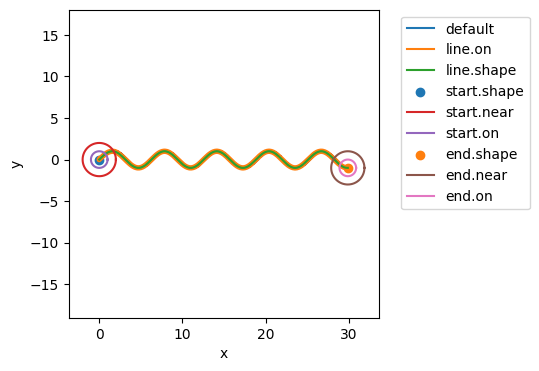

In [29]:
plot_map(mdl, hists)

In [30]:
ers.get_values("end_x")

rep0_range_0.tend.classify.end_x: 29.254775331608617
rep0_range_1.tend.classify.end_x: 29.254775331608617
rep0_range_2.tend.classify.end_x: 29.254775331608617
rep0_range_3.tend.classify.end_x: 29.254775331608617
rep0_range_4.tend.classify.end_x: 29.254775331608617
rep0_range_5.tend.classify.end_x: 29.254775331608617
rep0_range_6.tend.classify.end_x: 29.254775331608617
rep0_range_7.tend.classify.end_x: 29.254775331608617
rep0_range_8.tend.classify.end_x: 29.254775331608617
rep0_range_9.tend.classify.end_x: 29.254775331608617
rep0_range_10.tend.classify.end_x: 29.254775331608617
rep0_range_11.tend.classify.end_x: 29.254775331608617
rep0_range_12.tend.classify.end_x: 29.254775331608617
rep0_range_13.tend.classify.end_x: 29.254775331608617
rep0_range_14.tend.classify.end_x: 29.254775331608617
rep0_range_15.tend.classify.end_x: 29.254775331608617
rep0_range_16.tend.classify.end_x: 29.254775331608617
rep0_range_17.tend.classify.end_x: 29.254775331608617
rep0_range_18.tend.classify.end_x: 29.

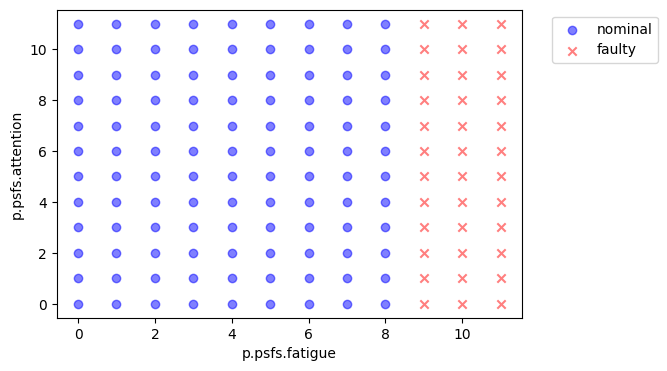

In [31]:
from fmdtools.analyze.tabulate import NominalEnvelope
na = NominalEnvelope(ps, ers, 'at_finish', 'p.psfs.fatigue', 'p.psfs.attention', func= lambda x: x)
fig, ax = na.plot_scatter()

In [32]:
fig.savefig("outputs_paper_idetc_human/nominal_psfs.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

In [33]:
mdl = RoverHuman(p={'ground': {'linetype': 'turn'}})
endresults, mdlhist = prop.one_fault(mdl, 'operator.aa.acts.look', 'failed_no_action', time=15)

In [34]:
endresults

nominal.tend.classify.rate:          1.0
nominal.tend.classify.cost:            0
nominal.tend.classify.prob:          1.0
nominal.tend.classify.expected_cost:   0
nominal.tend.classify.in_bound:     True
nominal.tend.classify.at_finish:    True
nominal.tend.classify.line_dist:       1
nominal.tend.classify.num_modes:       0
nominal.tend.classify.end_dist:      0.0
nominal.tend.classify.tot_deviation: 0.005246344989065292
nominal.tend.classify.faults:   array(0)
nominal.tend.classify.classification: nominal mission
nominal.tend.classify.end_x: 29.813614084369863
nominal.tend.classify.end_y: 17.26588133276667
nominal.tend.classify.endpt:    array(2)
operator_aa_acts_loo                 1.0
operator_aa_acts_loo                   0
operator_aa_acts_loo                 1.0
operator_aa_acts_loo                   0
operator_aa_acts_loo               False
operator_aa_acts_loo               False
operator_aa_acts_loo                   1
operator_aa_acts_loo                   1
operator_aa_ac

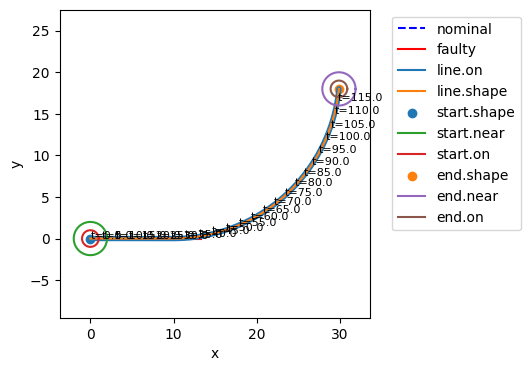

In [35]:
traj_fig = plot_map(mdl, mdlhist)

(<Figure size 400x400 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

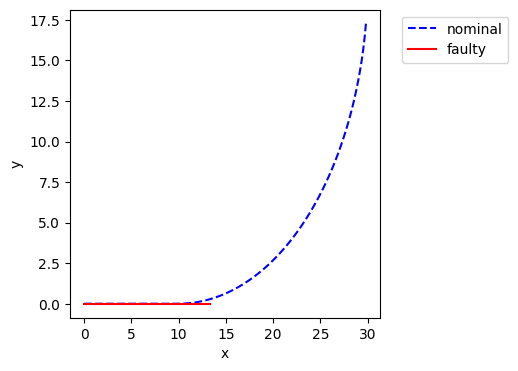

In [36]:
mdlhist.plot_trajectories('flows.pos.s.x', 'flows.pos.s.y')

(<Figure size 600x400 with 4 Axes>,
 array([<Axes: title={'center': 'flows.pos.s.vel'}, xlabel=' '>,
        <Axes: title={'center': 'flows.pos.s.ux'}, xlabel='time'>,
        <Axes: title={'center': 'flows.pos.s.uy'}, xlabel='time'>,
        <Axes: >], dtype=object))

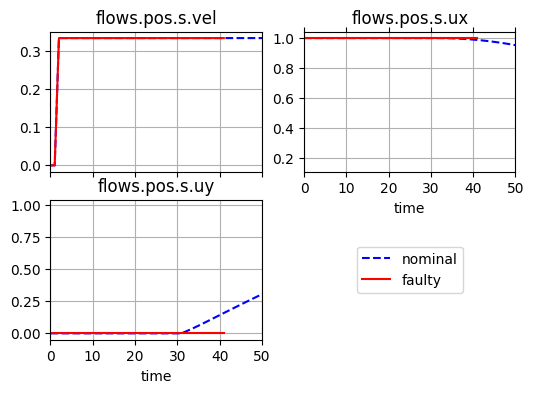

In [37]:
mdlhist.plot_line('flows.pos.s.vel', 'flows.pos.s.ux', 'flows.pos.s.uy')

In [38]:
fs = FaultSample(fd)
fs.add_fault_times([j for j in range(0, 30, 5)])
fs

FaultSample of scenarios: 
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t0
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t5
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t10
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t15
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t20
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t25
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t0
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t5
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t10
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t15
 - ... (114 total)

In [39]:
ers, hists = prop.fault_sample(mdl, fs)

SCENARIOS COMPLETE: 100%|██████████| 114/114 [00:44<00:00,  2.56it/s]


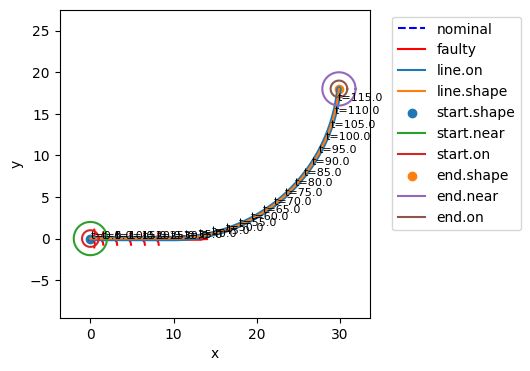

In [40]:
fig, ax = plot_map(mdl, hists)

In [41]:
fig.savefig("outputs_paper_idetc_human/nocon_trajectories.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

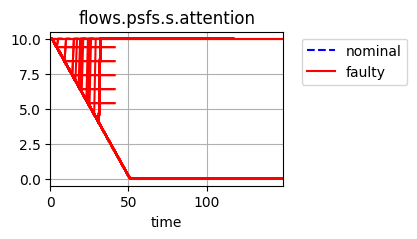

In [42]:
fig, ax = hists.plot_line('flows.psfs.s.attention')

In [43]:
fig.savefig("outputs_paper_idetc_human/nocon_attention.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

In [44]:
mdl = RoverHuman(p={'ground': {'linetype': 'sine', 'amp': 2, 'period': 2/3.14*30}})

In [45]:
ers, hists = prop.fault_sample(mdl, fs)

SCENARIOS COMPLETE: 100%|██████████| 114/114 [00:39<00:00,  2.89it/s]


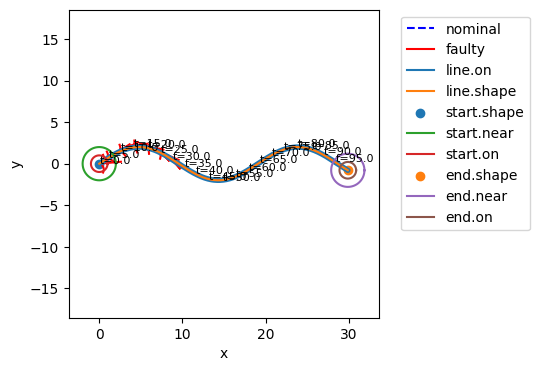

In [46]:
fig, ax = plot_map(mdl, hists)

In [47]:
fig.savefig("outputs_paper_idetc_human/nocon_trajectories_sine.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

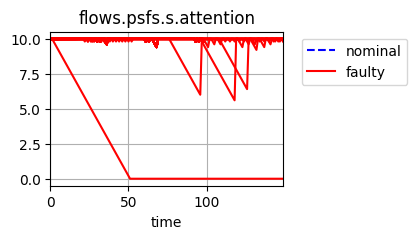

In [48]:
fig, ax = hists.plot_line('flows.psfs.s.attention')

In [50]:
fig.savefig("outputs_paper_idetc_human/nocon_attention_sine.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)